In [1]:
pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style("darkgrid")

In [3]:
data = pd.read_csv(r'C:/Users/ADITYA/Downloads/Machine failure prediction - Major project/data (1).csv')

In [ ]:
data.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB


In [6]:
# Data Preprocessing/
data = data.dropna(axis=1, how='all')  
data = data.loc[:, ~data.columns.str.contains('^$')]  
data.head(3)

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0


In [ ]:
data.groupby(['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']).median()

Empty DataFrame
Columns: []
Index: [(0, 0, 1, 4, 6, 1, 42, 7, 16, 0), (0, 0, 2, 2, 6, 1, 21, 5, 16, 0), (0, 0, 2, 3, 5, 1, 31, 7, 17, 0), (0, 0, 2, 3, 6, 1, 50, 6, 21, 0), (0, 0, 2, 4, 6, 0, 45, 6, 22, 0), (0, 0, 3, 2, 6, 1, 27, 3, 19, 0), (0, 0, 3, 3, 4, 2, 39, 3, 24, 0), (0, 0, 3, 3, 5, 2, 42, 3, 22, 0), (0, 0, 3, 3, 6, 0, 58, 4, 17, 0), (0, 0, 3, 3, 6, 3, 40, 4, 20, 0), (0, 0, 3, 4, 3, 3, 53, 7, 21, 1), (0, 0, 3, 4, 4, 0, 48, 6, 24, 0), (0, 0, 4, 1, 5, 4, 53, 3, 15, 1), (0, 0, 4, 2, 3, 4, 40, 3, 18, 1), (0, 0, 4, 2, 5, 4, 56, 7, 20, 1), (0, 0, 4, 2, 6, 6, 41, 7, 24, 1), (0, 0, 4, 4, 3, 1, 36, 3, 13, 0), (0, 0, 4, 4, 4, 3, 40, 3, 22, 0), (0, 0, 4, 4, 4, 3, 47, 4, 5, 0), (0, 0, 4, 6, 2, 5, 24, 4, 17, 1), (0, 0, 4, 6, 3, 3, 46, 5, 12, 0), (0, 0, 5, 2, 5, 4, 37, 5, 18, 1), (0, 0, 5, 2, 7, 3, 48, 7, 23, 1), (0, 0, 5, 4, 5, 2, 32, 3, 13, 1), (0, 0, 5, 4, 6, 4, 45, 3, 19, 0), (0, 0, 5, 4, 6, 5, 41, 7, 20, 1), (0, 0, 5, 6, 4, 1, 24, 4, 12, 0), (0, 0, 6, 1, 5, 4, 88, 4, 5, 1), (0, 0, 6, 1, 5, 6, 36, 6, 24, 1), (0, 0, 6, 1, 6, 5, 44, 6, 23, 1), (0, 0, 6, 1, 6, 6, 38, 3, 21, 1), (0, 0, 6, 1, 6, 6, 39, 5, 15, 1), (0, 0, 6, 1, 6, 6, 43, 6, 18, 1), (0, 0, 6, 2, 3, 5, 36, 4, 20, 1), (0, 0, 6, 2, 5, 5, 28, 3, 12, 1), (0, 0, 6, 2, 5, 6, 56, 3, 24, 1), (0, 0, 6, 2, 6, 6, 37, 6, 4, 1), (0, 0, 6, 2, 6, 6, 45, 6, 20, 1), (0, 0, 6, 2, 6, 6, 52, 3, 16, 1), (0, 0, 6, 3, 6, 6, 30, 6, 19, 1), (0, 0, 6, 4, 7, 3, 68, 6, 14, 0), (0, 0, 7, 1, 4, 6, 54, 6, 23, 1), (0, 0, 7, 3, 4, 5, 31, 3, 19, 1), (0, 1, 3, 2, 6, 1, 34, 6, 22, 0), (0, 1, 3, 2, 6, 1, 47, 6, 3, 0), (0, 1, 3, 4, 5, 2, 22, 6, 4, 0), (0, 1, 4, 3, 7, 1, 31, 3, 3, 0), (0, 1, 4, 4, 3, 5, 31, 3, 21, 1), (0, 1, 4, 4, 6, 1, 41, 4, 19, 0), (0, 1, 4, 4, 6, 5, 32, 6, 16, 0), (0, 1, 4, 5, 6, 2, 28, 6, 15, 0), (0, 1, 5, 2, 6, 2, 39, 2, 13, 0), (0, 1, 6, 1, 5, 6, 52, 7, 24, 1), (0, 1, 6, 1, 6, 5, 45, 4, 19, 1), (0, 1, 6, 2, 5, 5, 25, 3, 16, 1), (0, 1, 6, 2, 5, 5, 35, 5, 16, 1), (0, 1, 6, 2, 5, 6, 35, 7, 22, 1), (0, 1, 6, 2, 5, 6, 39, 5, 20, 1), (0, 1, 6, 2, 6, 6, 35, 4, 20, 1), (0, 1, 6, 2, 6, 6, 61, 3, 14, 1), (0, 1, 6, 3, 6, 6, 52, 6, 24, 1), (0, 1, 7, 2, 6, 6, 45, 4, 22, 1), (0, 2, 1, 2, 6, 0, 25, 6, 22, 0), (0, 2, 3, 5, 2, 0, 46, 3, 19, 0), (0, 2, 4, 2, 6, 1, 45, 3, 17, 0), (0, 2, 4, 2, 6, 4, 34, 6, 21, 1), (0, 2, 4, 3, 3, 6, 33, 3, 16, 1), (0, 2, 4, 3, 5, 5, 72, 7, 15, 1), (0, 2, 4, 3, 6, 0, 49, 4, 19, 0), (0, 2, 4, 3, 6, 1, 21, 4, 2, 0), (0, 2, 4, 3, 6, 1, 37, 3, 18, 0), (0, 2, 4, 3, 6, 2, 23, 6, 22, 0), (0, 2, 4, 4, 3, 5, 20, 3, 12, 1), (0, 2, 4, 4, 4, 0, 67, 1, 11, 0), (0, 2, 4, 5, 2, 0, 23, 2, 18, 0), (0, 2, 5, 1, 6, 4, 37, 3, 18, 1), (0, 2, 5, 2, 5, 4, 44, 6, 23, 1), (0, 2, 5, 2, 6, 4, 35, 6, 16, 0), (0, 2, 5, 2, 6, 5, 38, 3, 4, 1), (0, 2, 5, 3, 6, 5, 31, 7, 21, 1), (0, 2, 5, 3, 7, 2, 27, 5, 20, 0), (0, 2, 6, 1, 6, 5, 26, 5, 18, 1), (0, 2, 6, 1, 6, 5, 49, 4, 23, 1), (0, 2, 6, 1, 6, 6, 49, 4, 17, 1), (0, 2, 6, 1, 6, 6, 58, 6, 16, 1), (0, 2, 6, 1, 6, 6, 64, 3, 17, 1), (0, 2, 6, 2, 5, 6, 42, 7, 17, 1), (0, 2, 6, 2, 6, 6, 31, 5, 21, 1), (0, 2, 6, 2, 6, 6, 38, 3, 18, 1), (0, 2, 6, 3, 6, 1, 43, 4, 21, 1), (0, 2, 6, 4, 5, 4, 34, 4, 5, 1), (0, 2, 7, 1, 5, 5, 55, 3, 19, 1), (0, 2, 7, 2, 6, 5, 22, 3, 23, 1), (0, 3, 1, 2, 7, 2, 67, 7, 17, 0), (0, 3, 2, 2, 5, 1, 56, 7, 22, 0), (0, 3, 2, 2, 6, 1, 47, 7, 22, 0), (0, 3, 2, 3, 6, 3, 42, 3, 10, 0), (0, 3, 2, 3, 7, 0, 35, 7, 17, 0), (0, 3, 3, 3, 5, 0, 49, 7, 7, 0), (0, 3, 3, 3, 6, 1, 39, 6, 23, 0), ...]

[943 rows x 0 columns]

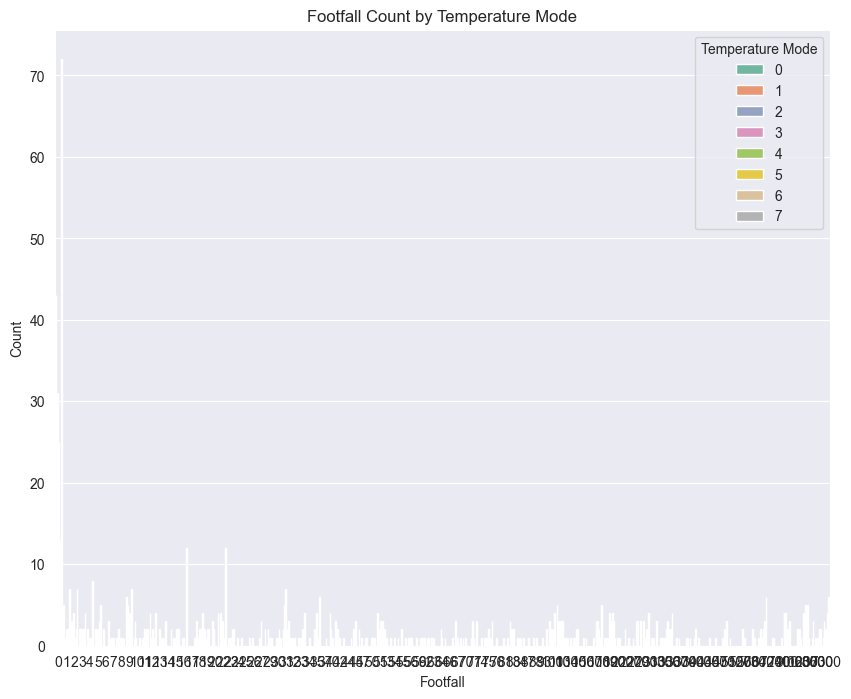

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(data=data, x="footfall", hue="tempMode", palette="Set2")
plt.title("Footfall Count by Temperature Mode")
plt.xlabel("Footfall")
plt.ylabel("Count")
plt.legend(title="Temperature Mode")

<Axes: xlabel='footfall', ylabel='count'>

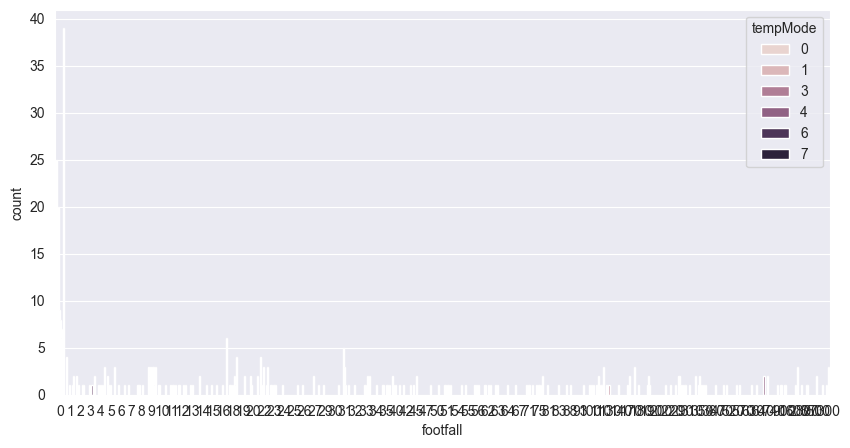

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=data[data['fail']==1], x="footfall", hue="tempMode")

<Figure size 1000x800 with 0 Axes>

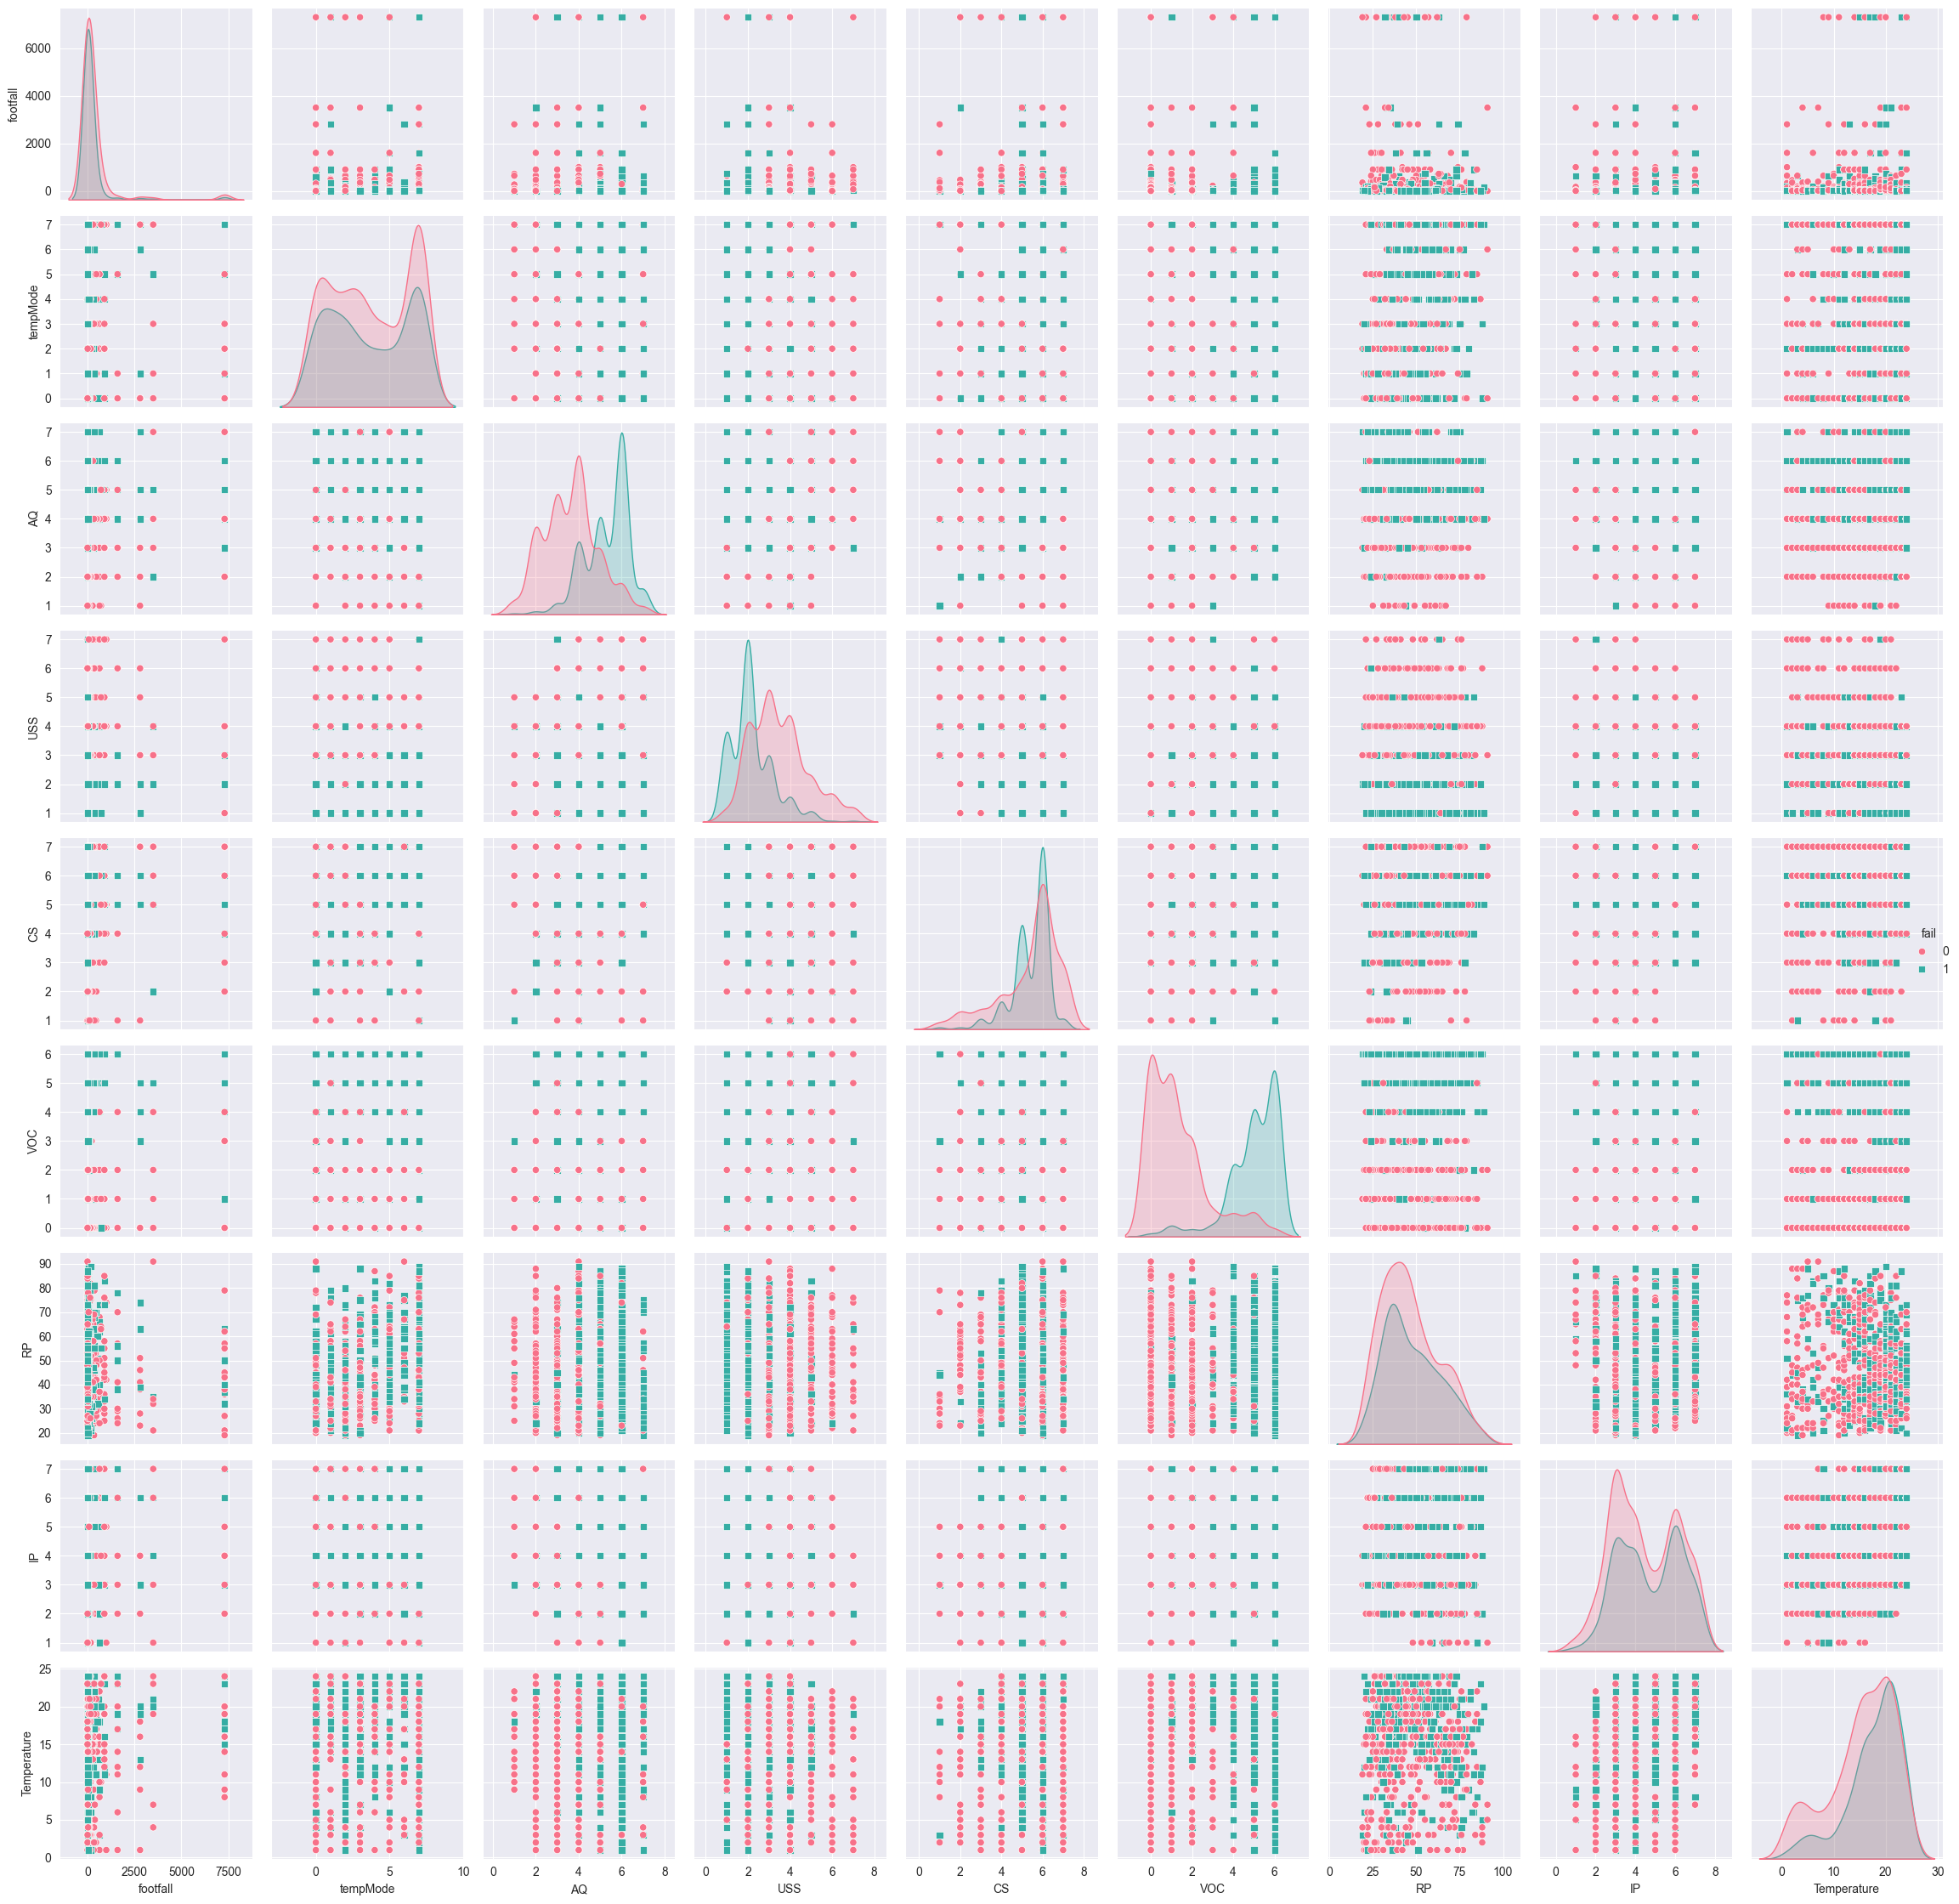

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.pairplot(data, hue='fail', vars=['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature'], markers=['o', 's'], palette='husl')
plt.tight_layout()
plt.show()

In [11]:
data.columns

Index(['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP',
       'Temperature', 'fail'],
      dtype='object')

In [ ]:
pip install plotly 

In [ ]:
pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install ipykernel

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import plotly.express as px

# Create a 3D scatter plot
fig = px.scatter_3d(
    data, 
    x='footfall', 
    y='tempMode', 
    z='AQ', 
    hover_name='USS', 
    hover_data=['CS', 'VOC', 'RP', 'IP', 'Temperature'],
    title='3D Scatter Plot of Footfall, Temperature Mode, and Air Quality',
    labels={'footfall': 'Footfall', 'tempMode': 'Temperature Mode', 'AQ': 'Air Quality'},
    color='tempMode', 
    color_continuous_scale='Viridis',
    template='plotly_white'  # Improved template for better visualization
)

# Update the layout
fig.update_layout(
    legend_title_text='Temperature Mode', 
    scene=dict(
        xaxis_title='Footfall',
        yaxis_title='Temperature Mode',
        zaxis_title='Air Quality',
        xaxis=dict(nticks=5),  # Improved tick count for better readability
        yaxis=dict(nticks=5),
        zaxis=dict(nticks=5)
    ),
    margin=dict(l=0, r=0, t=50, b=0)  # Improved margin for better layout
)

# Show the plot
fig.show()

In [16]:
def feat_prob(feature, data):
    x = data[feature].unique()
    y = [round((data[data[feature] >= j].tempmode.mean() * 100), 2) for j in x]
    return x, y

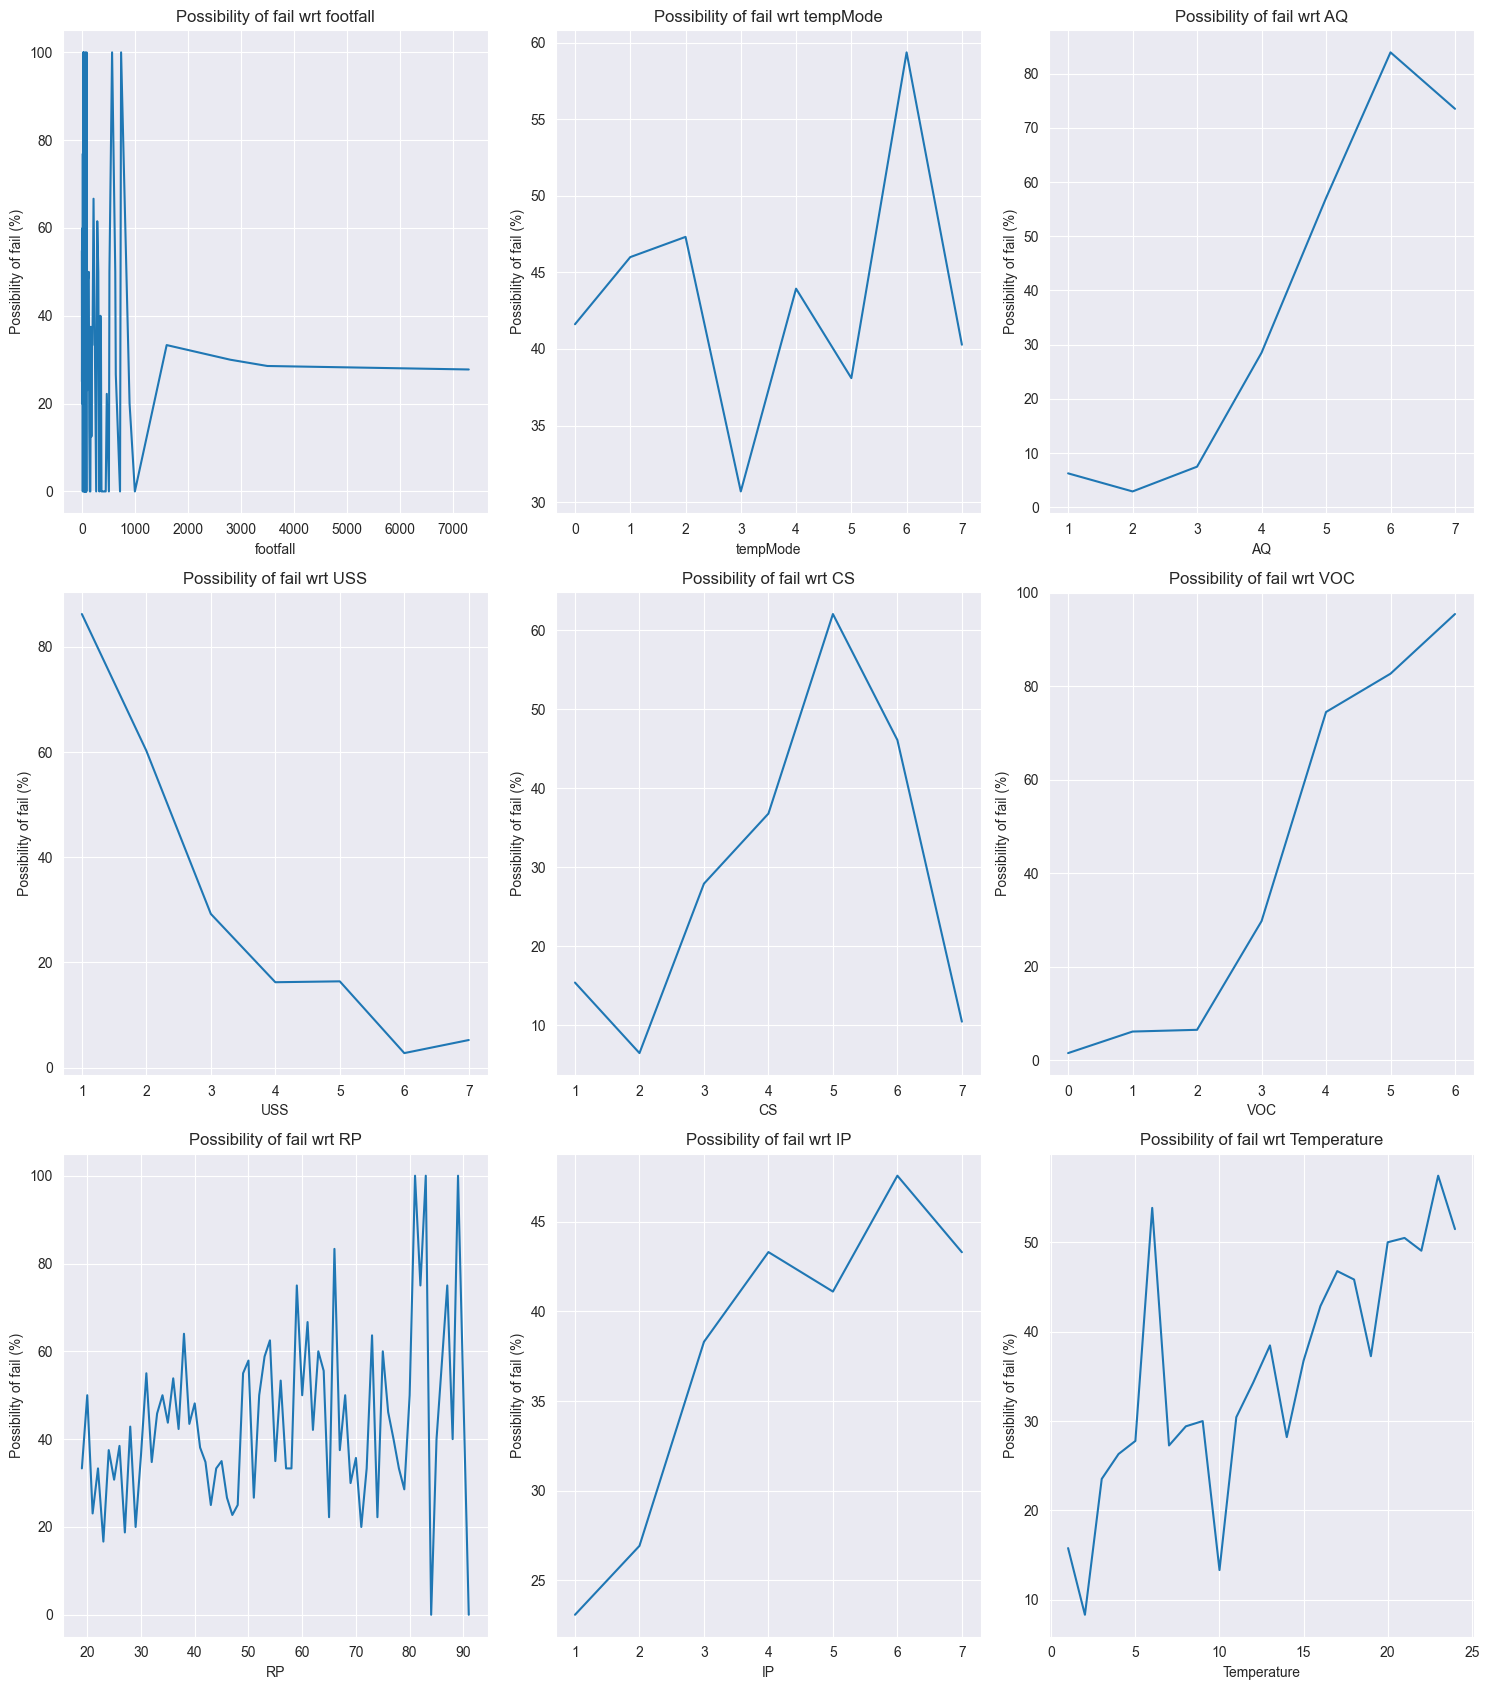

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the features to analyze
features = ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature']

# Function to calculate the possibility of fail for a given feature
def feat_prob(feature, data):
    grouped = data.groupby(feature)['fail'].mean() * 100  # Percentage of fail
    return grouped.index, grouped.values

# Create subplots for each feature
plt.figure(figsize=(15, 17))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1)
    plt.title(f"Possibility of fail wrt {feature}")
    x, y = feat_prob(feature, data)
    plt.xlabel(feature)
    plt.ylabel("Possibility of fail (%)")
    sns.lineplot(y=y, x=x)

plt.tight_layout()
plt.show()


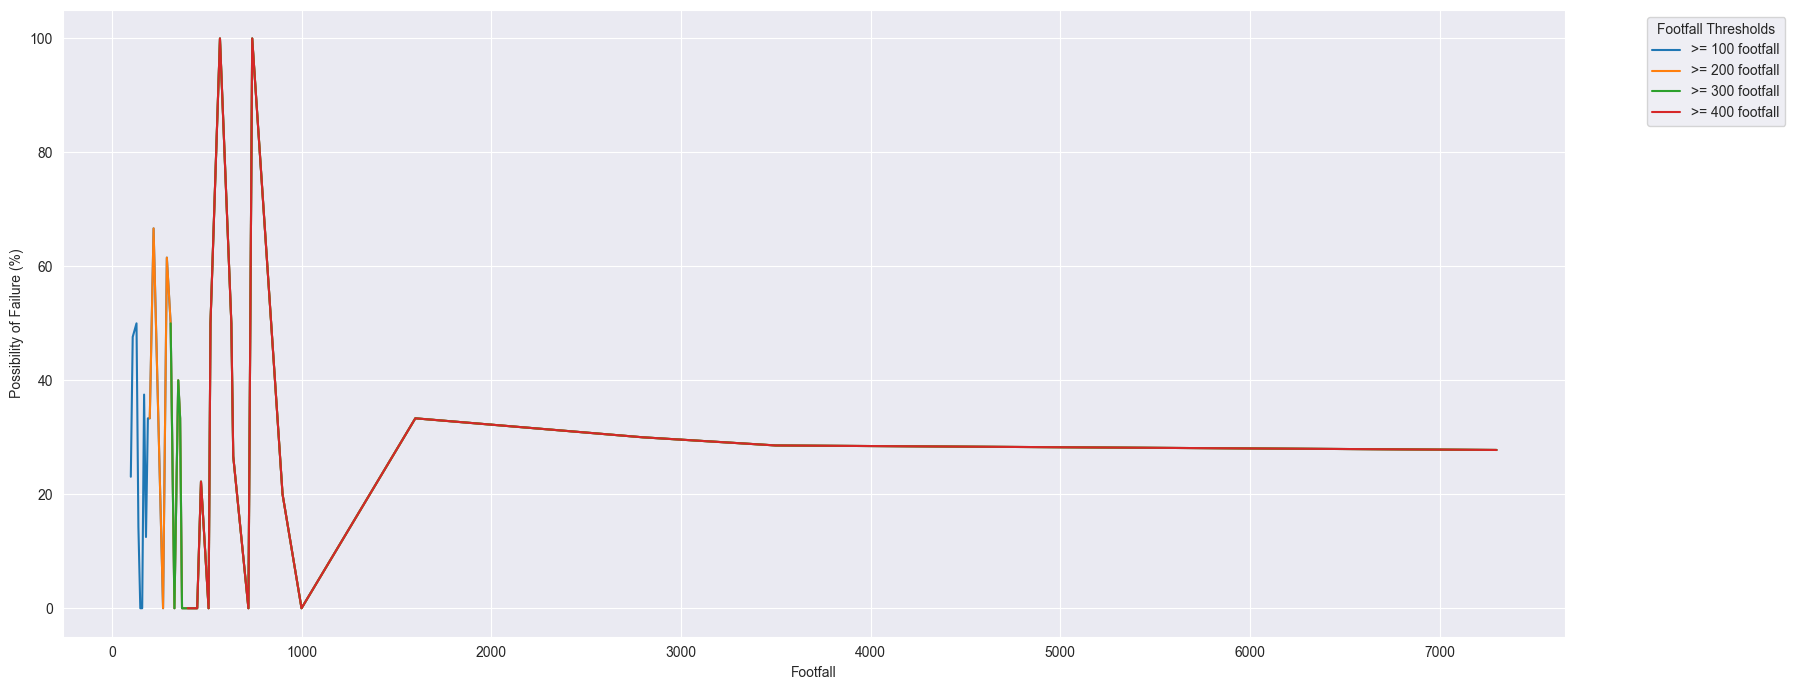

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define footfall thresholds for segmentation
footfall_thresholds = [100, 200, 300, 400]

# Create subsets of data based on the thresholds
datasets = [data[data['footfall'] >= threshold] for threshold in footfall_thresholds]

# Plot lines for each segmented dataset
plt.figure(figsize=(18, 7))
for i, dataset in enumerate(datasets):
    x, y = feat_prob("footfall", dataset)
    sns.lineplot(y=y, x=x, label=f'>= {footfall_thresholds[i]} footfall')

# Add labels, legend, and layout adjustments
plt.xlabel("Footfall")
plt.ylabel("Possibility of Failure (%)")
plt.legend(title="Footfall Thresholds", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


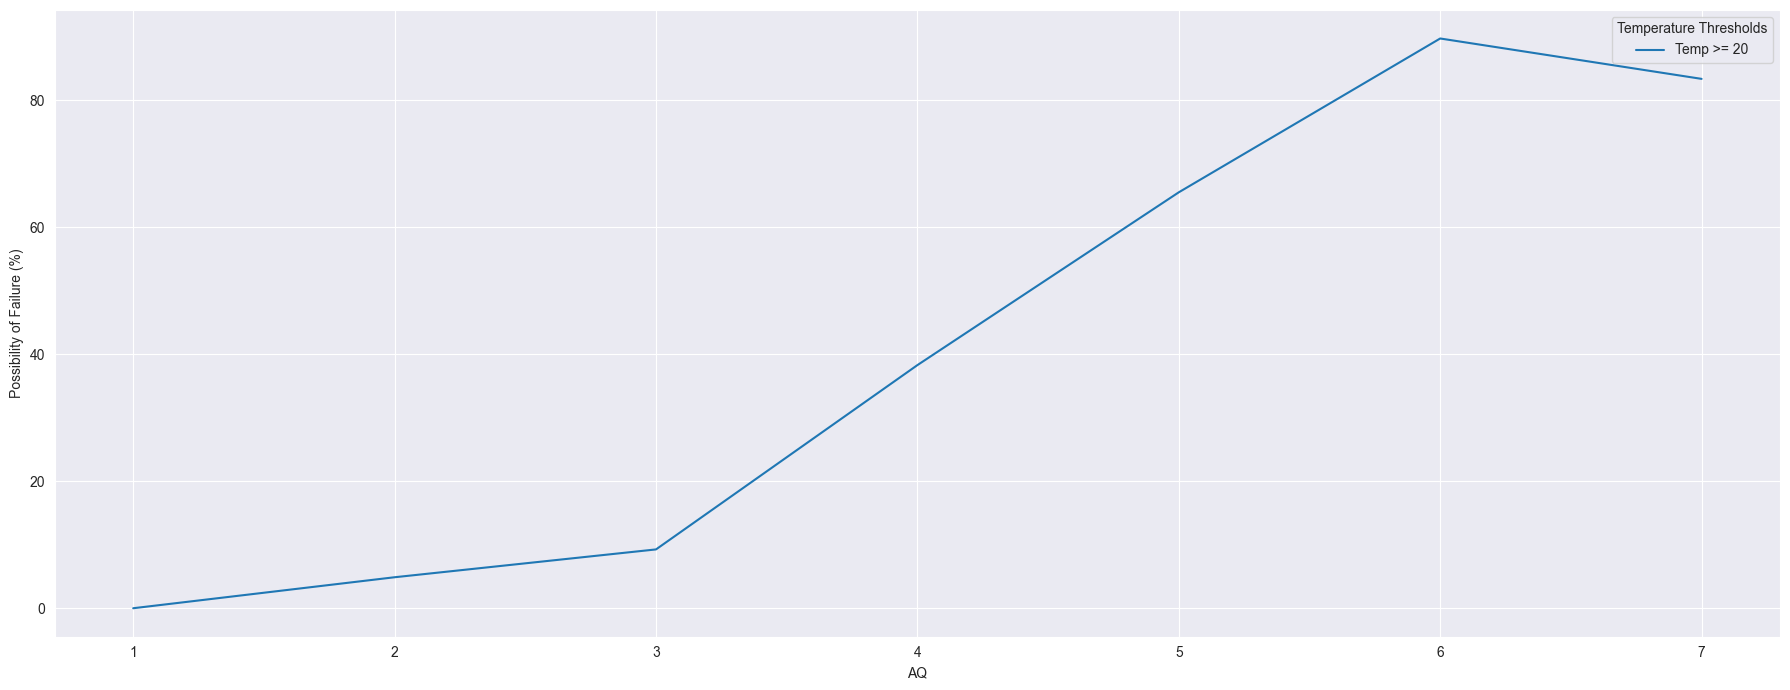

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the figure size
plt.figure(figsize=(18, 7))

# Create datasets for temperature thresholds
datasets = []
for threshold in [20, 40, 60]:
    datasets.append(data[data['Temperature'] >= threshold])

# Plot data for each threshold
for i, dataset in enumerate(datasets):
    x, y = feat_prob("AQ", dataset)
    if i == 0:
        plt.xlabel("AQ")
        plt.ylabel("Possibility of Failure (%)")
    sns.lineplot(y=y, x=x, label=f"Temp >= {20 * (i + 1)}")

# Add legend
plt.legend(title="Temperature Thresholds")
plt.tight_layout()
plt.show()


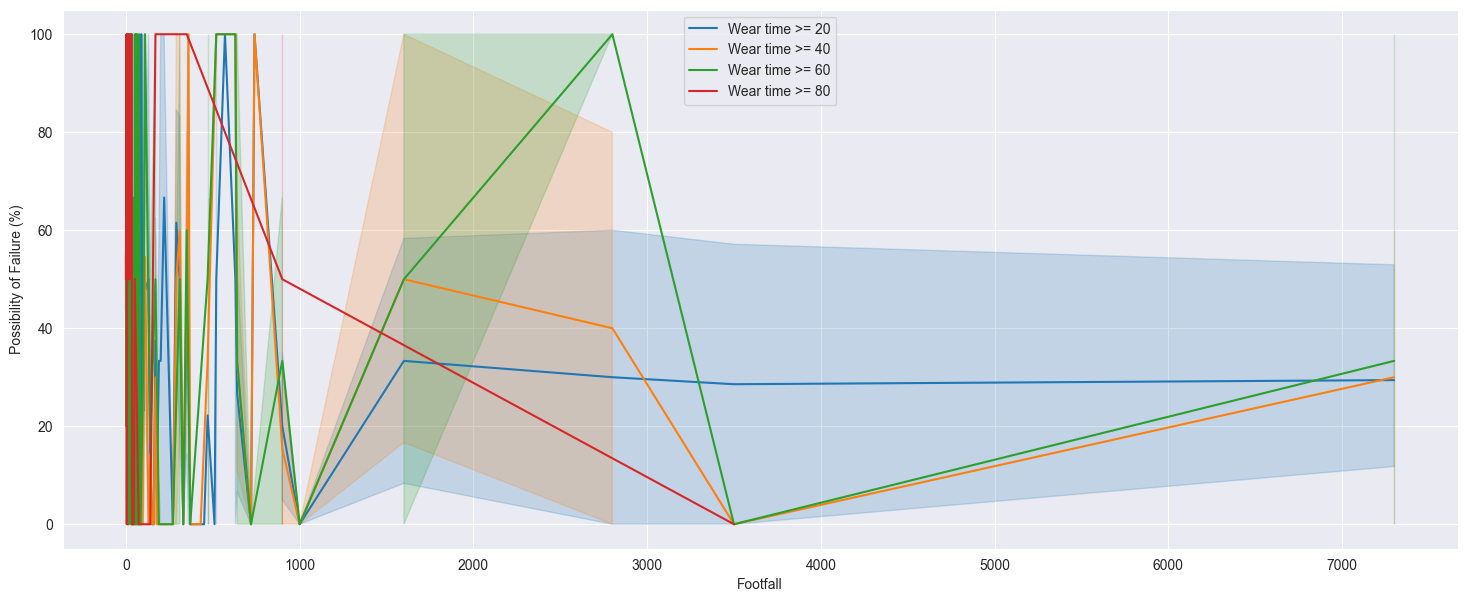

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv(r'C:/Users/ADITYA/Downloads/Machine failure prediction - Major project/data (1).csv')

# Define the function to calculate probabilities (dummy example)
def feat_prob(column, dataset):
    x = dataset[column]
    y = dataset['fail'] * 100  # Example: Probability is scaled from 'fail' column
    return x, y

# Define figure size
plt.figure(figsize=(18, 7))

# Define wear times or thresholds
wear_times = [20, 40, 60, 80]  # Adjust based on `RP` or any time-relevant column
datasets = [data[data['RP'] >= i] for i in wear_times]

# Iterate and plot
for i, dataset in enumerate(datasets):
    x, y = feat_prob('footfall', dataset)
    sns.lineplot(x=x, y=y, label=f"Wear time >= {wear_times[i]}")

# Add labels and legend
plt.xlabel("Footfall")
plt.ylabel("Possibility of Failure (%)")
plt.legend()
plt.show()


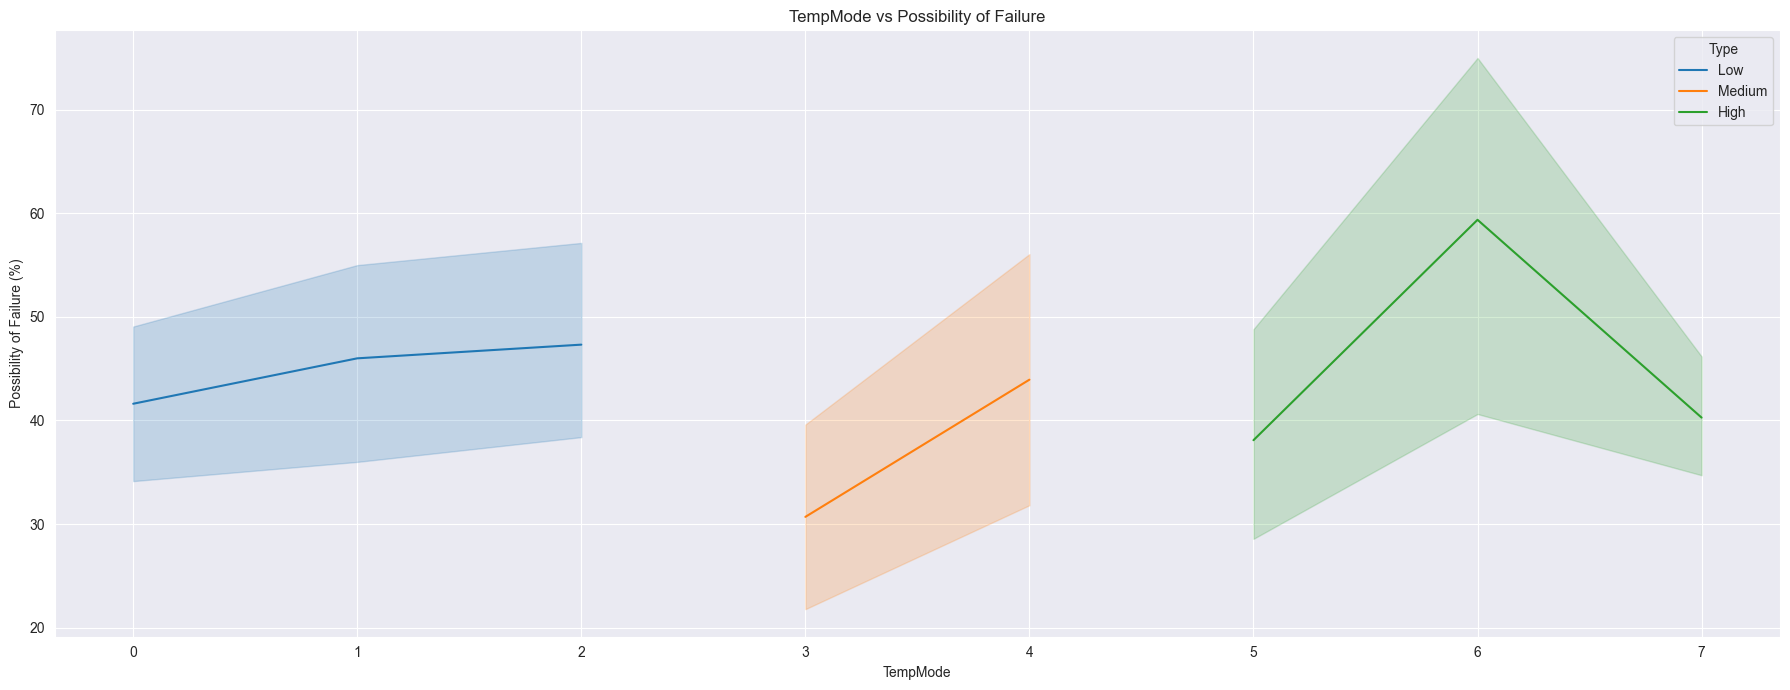

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
data = pd.read_csv(r'C:/Users/ADITYA/Downloads/Machine failure prediction - Major project/data (1).csv')

# Define feat_prob function
def feat_prob(column, dataset):
    x = dataset[column]
    y = dataset['fail'] * 100  # Convert binary fail to percentage
    return x, y

# Define figure size
plt.figure(figsize=(18, 7))

# Ensure monotonic bins for tempMode
min_value = data['tempMode'].min()
max_value = data['tempMode'].max()
mid1 = min_value + (max_value - min_value) / 3
mid2 = min_value + 2 * (max_value - min_value) / 3

# Create bins and labels
bins = [min_value, mid1, mid2, max_value]
categories = ["Low", "Medium", "High"]
data['Type'] = pd.cut(data['tempMode'], bins=bins, labels=categories, include_lowest=True)

# Filter datasets based on 'Type'
datasets = [data[data['Type'] == cat] for cat in categories]

# Plot data for each category
for i, dataset in enumerate(datasets):
    x, y = feat_prob("tempMode", dataset)
    sns.lineplot(x=x, y=y, label=categories[i])

# Add labels, title, and legend
plt.xlabel("TempMode")
plt.ylabel("Possibility of Failure (%)")
plt.title("TempMode vs Possibility of Failure")
plt.legend(title="Type")
plt.grid(True)
plt.tight_layout()
plt.show()




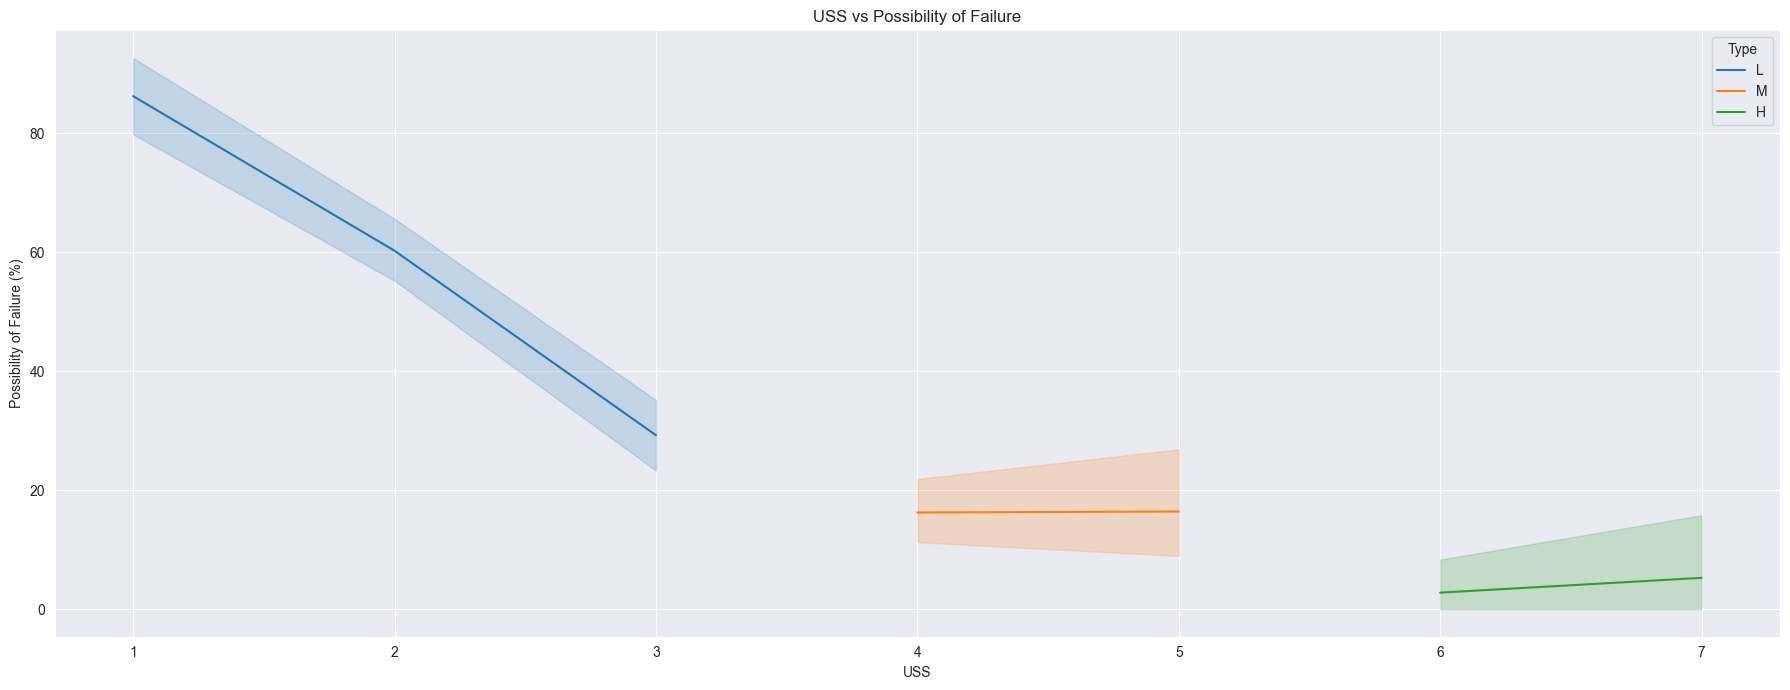

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv(r'C:/Users/ADITYA/Downloads/Machine failure prediction - Major project/data (1).csv')

# Placeholder feat_prob function
def feat_prob(column, dataset):
    x = dataset[column]
    y = dataset['fail'] * 100  # Convert binary fail to percentage
    return x, y

# Calculate monotonic bins for 'USS'
min_value = data['USS'].min()
max_value = data['USS'].max()
mid1 = min_value + (max_value - min_value) / 3
mid2 = min_value + 2 * (max_value - min_value) / 3

bins = [min_value, mid1, mid2, max_value]  # Monotonic increasing bins
categories = ["L", "M", "H"]
data['Type'] = pd.cut(data['USS'], bins=bins, labels=categories, include_lowest=True)

# Initialize figure
plt.figure(figsize=(18, 7))

# Filter datasets for each type
datasets = [data[data['Type'] == cat] for cat in categories]

# Iterate over datasets and plot
for i, dataset in enumerate(datasets):
    x, y = feat_prob("USS", dataset)
    sns.lineplot(x=x, y=y, label=categories[i])

# Add labels and legend
plt.xlabel("USS")
plt.ylabel("Possibility of Failure (%)")
plt.title("USS vs Possibility of Failure")
plt.legend(title="Type")
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
import pandas as pd

# Load the dataset
data = pd.read_csv(r'C:/Users/ADITYA/Downloads/Machine failure prediction - Major project/data (1).csv')

# Create the new 'nf' column as the product of 'footfall' and 'tempMode'
data['nf'] = data['footfall'] * data['tempMode']

# Display the first few rows of the updated dataset
print(data[['footfall', 'tempMode', 'nf']].head())


   footfall  tempMode    nf
0         0         7     0
1       190         1   190
2        31         7   217
3        83         4   332
4       640         7  4480


<Axes: xlabel='nf', ylabel='AQ'>

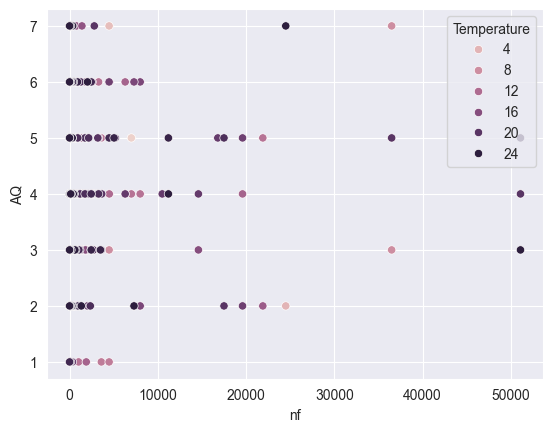

In [34]:
sns.scatterplot(data=data,x='nf',y='AQ',hue='Temperature')

In [54]:
pip install -U scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.1 MB 2.4 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.1 MB 2.5 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.1 MB 2.7 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.1 MB 2.8 MB/s eta 0:00:04
   ------------- -------------------------- 3.7/11.1 MB 3.0 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 3.2 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 3.2 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 3.2 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 3.2 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/11.1 MB 2.0 MB/s eta 0:00:04
   ------------------ --------------------- 5.2/11.1 MB 2.1 MB/s eta 0:00:03
   ----------

In [55]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Define a function to encode categorical columns
def encode_categorical_columns(data, columns):
    for column in columns:
        if column in data.columns:
            label_encoder.fit(data[column])
            data[column] = label_encoder.transform(data[column])
    return data

# Example usage: Encoding categorical columns
categorical_columns = ['fail']  # Replace with actual categorical columns
data = encode_categorical_columns(data, categorical_columns)

# Display the first few rows to confirm encoding
print(data.head())


   footfall  tempMode  AQ  USS  CS  VOC  RP  IP  Temperature  fail    nf
0         0         7   7    1   6    6  36   3            1     1     0
1       190         1   3    3   5    1  20   4            1     0   190
2        31         7   2    2   6    1  24   6            1     0   217
3        83         4   3    4   5    1  28   6            1     0   332
4       640         7   5    6   4    0  68   6            1     0  4480


In [56]:
data.tail()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail,nf
939,0,7,7,1,6,4,73,6,24,1,0
940,0,7,5,2,6,6,50,6,24,1,0
941,0,3,6,2,7,5,43,6,24,1,0
942,0,6,6,2,5,6,46,7,24,1,0
943,18,7,4,2,6,3,61,7,24,1,126


In [57]:
from sklearn.model_selection import train_test_split

In [58]:
from sklearn.model_selection import train_test_split

# Define features and target
X = data.drop(['fail'], axis=1)  # Drop 'fail' as it's the target variable
y = data['fail']  # Use 'fail' as the target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shapes of the splits
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (660, 10)
X_test shape: (284, 10)
y_train shape: (660,)
y_test shape: (284,)


In [60]:
pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------------------------------------ --- 1.3/1.4 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 7.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [66]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# Initialize lists to store classifiers and their labels
classifier = []
imported_as = []

# LightGBM
import lightgbm as lgb
lgbm = lgb.LGBMClassifier()
classifier.append('LightGBM')
imported_as.append('lgbm')

# Multi-Layer Perceptron
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier()
classifier.append('Multi Layer Perceptron')
imported_as.append('mlp')

# Bagging Classifier
from sklearn.ensemble import BaggingClassifier
bc = BaggingClassifier()
classifier.append('Bagging')
imported_as.append('bc')

# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
classifier.append('Gradient Boosting')
imported_as.append('gbc')

# AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
classifier.append('Ada Boost')
imported_as.append('ada')

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier
xgb_clf = XGBClassifier() 
classifier.append('XG Boost')
imported_as.append('xgb_clf')

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
classifier.append('Logistic Regression')
imported_as.append('lr')

# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
classifier.append('Random Forest')
imported_as.append('rfc')

# k-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
classifier.append('k Nearest Neighbours')
imported_as.append('knn')

# Support Vector Machine (SVM)
from sklearn.svm import SVC
svc = SVC()
classifier.append('Support Vector Machine')
imported_as.append('svc')

# SVM with GridSearchCV for Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10, 100, 1000, 2000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
classifier.append('SVM Tuning Grid')
imported_as.append('grid')

# Stacking Classifier
from sklearn.ensemble import StackingClassifier
estimators = [('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
              ('svr', SVC(probability=True, random_state=42))]
stc = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
classifier.append('Stacked (RFR & SVM)')
imported_as.append('stc')

# Create a DataFrame to store all classifiers and their references
classifiers = pd.DataFrame({'Classifier': classifier, 'Imported as': imported_as})

# Print confirmation and display the classifiers DataFrame
print('All Models Imported')
print('Models stored in a DataFrame called classifiers')
print(classifiers)


All Models Imported
Models stored in a DataFrame called classifiers
                Classifier Imported as
0                 LightGBM        lgbm
1   Multi Layer Perceptron         mlp
2                  Bagging          bc
3        Gradient Boosting         gbc
4                Ada Boost         ada
5                 XG Boost     xgb_clf
6      Logistic Regression          lr
7            Random Forest         rfc
8     k Nearest Neighbours         knn
9   Support Vector Machine         svc
10         SVM Tuning Grid        grid
11     Stacked (RFR & SVM)         stc


In [67]:
class Modelling:
    def __init__(self, X_train, Y_train, X_test, Y_test, models):
        self.X_train = X_train
        self.X_test = X_test
        self.Y_train = Y_train
        self.Y_test = Y_test
        self.models = models  # List of model instances
        self.best = None
        self.models_output = None

    def fit(self):
        model_acc = []
        model_time = []

        for model in self.models:
            start = time.time()

            # Handle special case for KNN to find the best number of neighbors
            if isinstance(model, KNeighborsClassifier):
                accuracy = []
                for j in range(1, 200):
                    kn = KNeighborsClassifier(n_neighbors=j)
                    kn.fit(self.X_train, self.Y_train)
                    predK = kn.predict(self.X_test)
                    accuracy.append((accuracy_score(self.Y_test, predK), j))
                
                # Select the best number of neighbors
                best_k = max(accuracy, key=lambda x: x[0])[1]
                model = KNeighborsClassifier(n_neighbors=best_k)

            # Fit the model
            model.fit(self.X_train, self.Y_train)
            
            # Record accuracy and runtime
            acc = accuracy_score(self.Y_test, model.predict(self.X_test))
            model_acc.append(acc)
            stop = time.time()
            model_time.append(stop - start)
            
            print(f"{model} has been fit with accuracy: {acc:.4f}")

        # Store model results
        self.models_output = pd.DataFrame({'Models': self.models, 'Accuracy': model_acc, 'Runtime (s)': model_time})

    def results(self):
        models = self.models_output.sort_values(by=['Accuracy', 'Runtime (s)'], ascending=[False, True]).reset_index(drop=True)
        self.best = models['Models'][0]  # Save the best model
        models['Models'] = models['Models'].astype(str).str.split("(", n=1, expand=True)[0]
        models['Accuracy'] = (models['Accuracy'] * 100).round(2)  # Convert accuracy to percentage
        self.models_output_cleaned = models
        return models

    def best_model(self, type):
        if type == 'model':
            return self.best
        elif type == 'name':
            return str(self.best).split("(")[0]

    def best_model_accuracy(self):
        return self.models_output_cleaned.iloc[0]['Accuracy']

    def best_model_runtime(self):
        return round(self.models_output_cleaned.iloc[0]['Runtime (s)'], 3)

    def best_model_predict(self, X_test):
        return self.best.predict(X_test)

    def best_model_clmatrix(self):
        from sklearn.metrics import classification_report
        return classification_report(self.Y_test, self.best.predict(self.X_test))


In [69]:
display(classifiers)

,Classifier,Imported as
0,LightGBM,lgbm
1,Multi Layer Perceptron,mlp
2,Bagging,bc
3,Gradient Boosting,gbc
4,Ada Boost,ada
5,XG Boost,xgb_clf
6,Logistic Regression,lr
7,Random Forest,rfc
8,k Nearest Neighbours,knn
9,Support Vector Machine,svc


In [70]:
models_to_test = [bc,gbc,ada,rfc,mlp,lr,knn,stc]

In [72]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 660 entries, 442 to 102
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     660 non-null    int64
 1   tempMode     660 non-null    int64
 2   AQ           660 non-null    int64
 3   USS          660 non-null    int64
 4   CS           660 non-null    int64
 5   VOC          660 non-null    int64
 6   RP           660 non-null    int64
 7   IP           660 non-null    int64
 8   Temperature  660 non-null    int64
 9   nf           660 non-null    int64
dtypes: int64(10)
memory usage: 56.7 KB


In [73]:
classification = Modelling(X_train,y_train,X_test,y_test,models_to_test)
classification.fit()

BaggingClassifier() has been fit with accuracy: 0.8486
GradientBoostingClassifier() has been fit with accuracy: 0.8838
AdaBoostClassifier() has been fit with accuracy: 0.8732
RandomForestClassifier() has been fit with accuracy: 0.8838
MLPClassifier() has been fit with accuracy: 0.8345
LogisticRegression() has been fit with accuracy: 0.8803


c:\Users\ADITYA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



KNeighborsClassifier(n_neighbors=4) has been fit with accuracy: 0.7218
StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(n_estimators=10,
                                                       random_state=42)),
                               ('svr', SVC(probability=True, random_state=42))],
                   final_estimator=LogisticRegression()) has been fit with accuracy: 0.8697


In [74]:
classification.results()

,Models,Accuracy,Runtime (s)
0,GradientBoostingClassifier,88.38,0.156689
1,RandomForestClassifier,88.38,0.248034
2,LogisticRegression,88.03,0.039011
3,AdaBoostClassifier,87.32,0.117683
4,StackingClassifier,86.97,0.614558
5,BaggingClassifier,84.86,0.036243
6,MLPClassifier,83.45,0.116574
7,KNeighborsClassifier,72.18,4.529048


In [75]:
print('BestModel is:',  classification.best_model(type='name'))
print('Accuracy of model:',classification.best_model_accuracy())
print('Training Runtime in seconds',classification.best_model_runtime())
print('Classification Matrix:\n')
print(classification.best_model_clmatrix())

BestModel is: GradientBoostingClassifier
Accuracy of model: 88.38
Training Runtime in seconds 0.157
Classification Matrix:

              precision    recall  f1-score   support

           0       0.91      0.88      0.90       160
           1       0.85      0.89      0.87       124

    accuracy                           0.88       284
   macro avg       0.88      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284



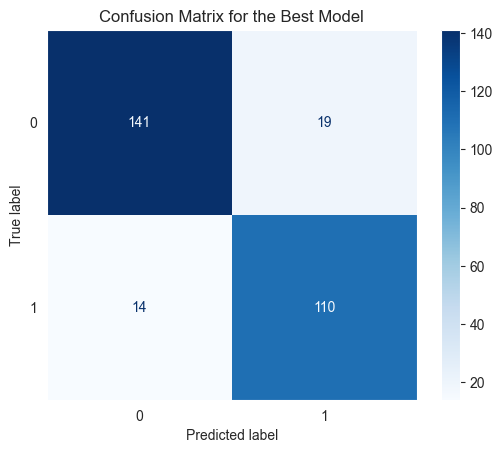

In [ ]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Set Seaborn style
sns.set_style("darkgrid", {"grid.color": "1", "grid.linestyle": " "})

# Plot confusion matrix for the best model
best_model = classification.best_model(type='model')  # Get the best model instance
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')

# Show the plot
plt.title("Confusion Matrix for the Best Model")
plt.show()
